In [ ]:
import boto3
import s3fs
import zarr
import torch
from torch_geometric.data import Data

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from src.train_cnn import ResNetUNet
from src.train_gat import FloorplanGNN
from src.utils import *

s3 = boto3.client("s3")

In [3]:
%store -r

# Extracting Model Artifacts

In [ ]:
STATE_DICT_CNN = f"{s3_project_prefix}/models/model_artifacts/pipelines-we82lejaox5y-TrainInteriorBoundsM-i8k96yaPTB/output/model.tar.gz"
STATE_DICT_GAT = f"{s3_project_prefix}/models/model_artifacts/gat/pipelines-g74eu4gn1fgf-TrainGATModel-ajs5kHDnKX/output/model.tar.gz"

archive_path = "model.tar.gz"
state_dict_path = "model_best.pth"
resnet_extract_dir = "./extracted_model/resnet"
gnn_extract_dir = "./extracted_model/gnn"

In [ ]:
cnn_state_dict_path = download_and_extract_state_dict(
    STATE_DICT_CNN,
    model_artifact=archive_path,
    state_dict_path=state_dict_path,
    extract_dir=resnet_extract_dir,
)

gat_state_dict_path = download_and_extract_state_dict(
    STATE_DICT_GAT,
    model_artifact=archive_path,
    state_dict_path=state_dict_path,
    extract_dir=gnn_extract_dir,
)

Extracting to ./extracted_model/resnet ...
Found model_best.pth at ./extracted_model/resnet/model_best.pth
Extracting to ./extracted_model/gnn ...
Found model_best.pth at ./extracted_model/gnn/model_best.pth


In [6]:
cnn_state_dict_path

'./extracted_model/resnet/model_best.pth'

In [7]:
cnn_model = model_fn(cnn_state_dict_path, ResNetUNet())
gat_model = model_fn(gat_state_dict_path, FloorplanGNN())

# Inference

In [ ]:
val_indices = np.load("val_indices.npy")

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f"{s3_project_prefix}/store/data.zarr", s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode="r")

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f46b41320c0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f46bd6e4ad0>, 23082.383884293)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f46b410e450>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f46b4197440>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f46bd6e4b30>, 23082.393248321)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f46b4133200>


In [ ]:
# Load sample
val_idx = val_indices[10]

boundary_mask_gt = z["boundary_masks"][val_idx]
inside_mask_gt = z["inside_masks"][val_idx]
room_mask_gt = z["room_masks"][val_idx]
door_mask_gt = z["door_masks"][val_idx]

boundary_mask_in = (
    torch.Tensor(boundary_mask_gt).to("cpu").float().unsqueeze(0)
)  # (H,W) -> (1,H,W)
inside_mask_in = (
    torch.Tensor(inside_mask_gt).to("cpu").float().unsqueeze(0)
)  # (H,W) -> (1,H,W)

## Stage 1: Generate Interior Boundaries

In [ ]:
with torch.no_grad():
    pred = cnn_model(inside_mask_in, boundary_mask_in)

# Output is (1, 1, H, W) — squeeze back down for visualization
pred_room = torch.sigmoid(pred["room_mask"]).squeeze().numpy()  # (H,W)
pred_door = torch.sigmoid(pred["door_mask"]).squeeze().numpy()

In [11]:
pred_room_bin = model_thresholding(pred_room, 0.20)
pred_door_bin = model_thresholding(pred_door, 0.15)

pred_post_processed = post_process_stacked_layers(pred_room_bin, pred_door_bin)

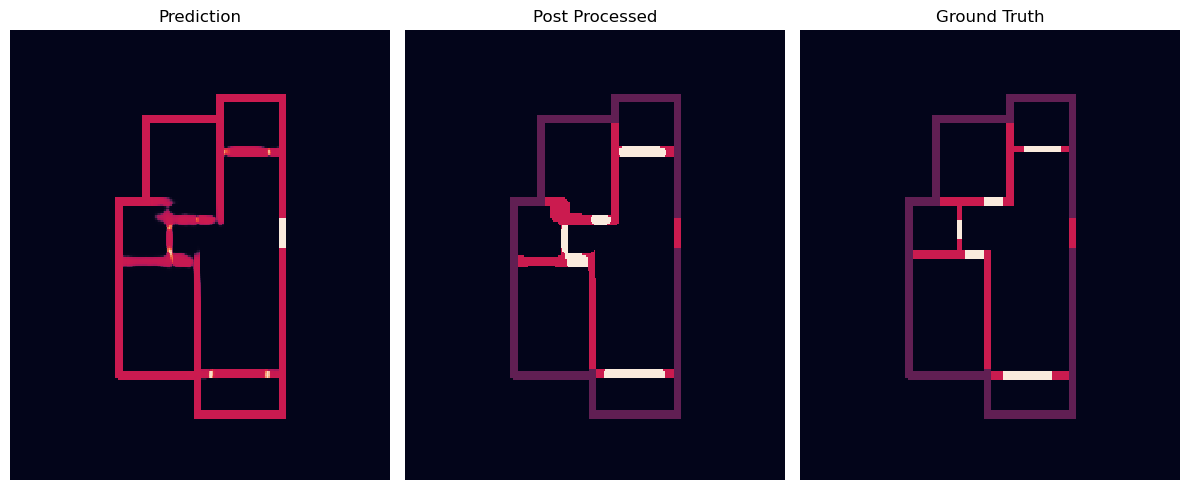

In [ ]:
input_arrs = np.sum([boundary_mask_gt, room_mask_gt * 2, door_mask_gt * 4], axis=0)
stacked_layers_nt = np.sum([pred_room, pred_door], axis=0)

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(
    np.sum([boundary_mask_gt, stacked_layers_nt], axis=0),
    ax=ax[0],
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
ax[0].set_title("Prediction")

sns.heatmap(
    np.sum([boundary_mask_gt, pred_post_processed], axis=0),
    ax=ax[1],
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
ax[1].set_title("Post Processed")

sns.heatmap(input_arrs, cbar=False, xticklabels=False, yticklabels=False)
ax[2].set_title("Ground Truth")

plt.tight_layout()
plt.show()

## Stage 2: Graph Extraction & Node Prediction

In [ ]:
# Graph extraction
stacked_layers = stack_normalize(boundary_mask_gt, pred_room_bin, pred_door_bin)
num_labels, labels, stats, centroids = conn_components(
    inside_mask_gt, boundary_mask_gt, pred_room_bin, pred_door_bin
)
rwb = rooms_with_bounds(stacked_layers, labels)
adj_graph = extract_all_adjacencies(rwb)
src, dst, attr = edge_arrays(adj_graph)

edge_index = np.array([src, dst])
edge_attr = np.array(attr)
node_features = np.array(node_array(centroids[1:, :], stats[1:, :]))

In [14]:
adj_graph

,n1,n2,adj_type,edge_strength
0,5,6,0,14
2,5,7,1,28
4,6,7,1,8
5,6,8,0,17
7,7,8,1,11
8,7,9,0,62
10,7,10,1,35
11,8,9,0,30


In [15]:
node_features

array([[ 162.07807487,   53.13903743,  935.        ],
       [ 117.03331812,   77.07120037, 2191.        ],
       [ 154.39556071,  135.26536359, 6037.        ],
       [  89.55845771,  114.28109453,  804.        ],
       [  99.43629344,  163.81993682, 2849.        ],
       [ 154.5       ,  206.5       ,  936.        ]])

In [16]:
edge_index

array([[ 5,  5,  6,  6,  7,  7,  7,  8],
       [ 6,  7,  7,  8,  8,  9, 10,  9]])

In [17]:
edge_attr

array([[ 0., 14.],
       [ 1., 28.],
       [ 1.,  8.],
       [ 0., 17.],
       [ 1., 11.],
       [ 0., 62.],
       [ 1., 35.],
       [ 0., 30.]])

<Axes: >

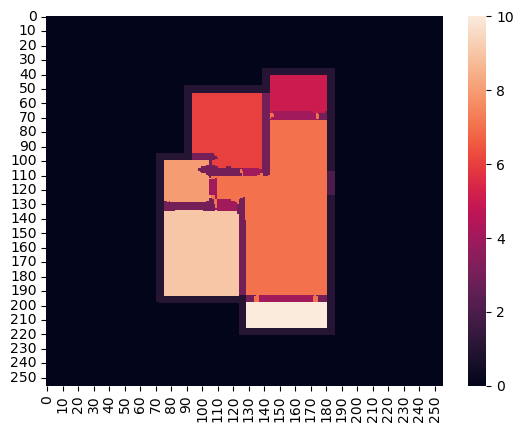

In [18]:
sns.heatmap(rwb)

In [ ]:
def gat_input(node_features, edge_index, edge_attr):
    # Input scaling
    x = torch.from_numpy(node_features).float()
    x[:, :2] /= 256.0
    x[:, 2] /= 10000.0

    ei = torch.from_numpy(edge_index - 5).long()
    ea = torch.from_numpy(edge_attr.T).float()

    # --- make bidirectional ---
    ei = torch.cat([ei, ei.flip(0)], dim=1)
    ea = torch.cat([ea, ea], dim=1)

    # --- final shape for PyG ---
    ea = ea.T.contiguous()  # [E, 2]

    return Data(x=x, edge_index=ei, edge_attr=ea)

In [20]:
input_data = gat_input(node_features, edge_index, edge_attr)
print(input_data.x)
print(input_data.edge_index)
print(input_data.edge_attr)

tensor([[0.6331, 0.2076, 0.0935],
        [0.4572, 0.3011, 0.2191],
        [0.6031, 0.5284, 0.6037],
        [0.3498, 0.4464, 0.0804],
        [0.3884, 0.6399, 0.2849],
        [0.6035, 0.8066, 0.0936]])
tensor([[0, 0, 1, 1, 2, 2, 2, 3, 1, 2, 2, 3, 3, 4, 5, 4],
        [1, 2, 2, 3, 3, 4, 5, 4, 0, 0, 1, 1, 2, 2, 2, 3]])
tensor([[ 0., 14.],
        [ 1., 28.],
        [ 1.,  8.],
        [ 0., 17.],
        [ 1., 11.],
        [ 0., 62.],
        [ 1., 35.],
        [ 0., 30.],
        [ 0., 14.],
        [ 1., 28.],
        [ 1.,  8.],
        [ 0., 17.],
        [ 1., 11.],
        [ 0., 62.],
        [ 1., 35.],
        [ 0., 30.]])


In [21]:
logits = gat_model(input_data)
print(logits.shape)

pred_gat = logits.argmax(dim=-1)
print(pred_gat)

vocab = get_vocab()["object_idx_to_name"]

pred_gat_labels = [vocab[i] for i in pred_gat]
print(pred_gat_labels)

torch.Size([6, 13])
tensor([2, 7, 0, 3, 1, 9])
['Kitchen', 'SecondRoom', 'LivingRoom', 'Bathroom', 'MasterRoom', 'Balcony']


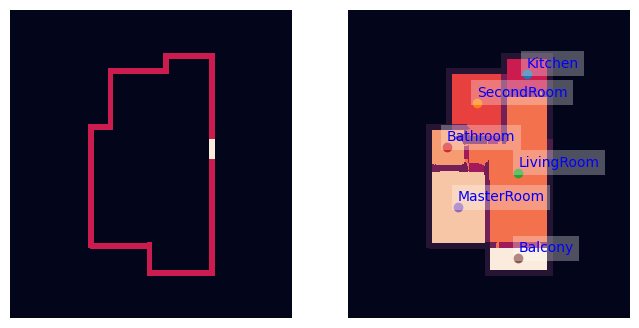

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.heatmap(
    boundary_mask_gt, xticklabels=False, yticklabels=False, cbar=False, ax=ax[0]
)
sns.heatmap(rwb, xticklabels=False, yticklabels=False, cbar=False, ax=ax[1])

for node, label in zip(node_features, pred_gat_labels):
    ax[1].scatter(node[0], node[1])
    ax[1].text(
        node[0],
        node[1] - 5,
        label,
        color="blue",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.3),
    )

# Batch Transform

In [22]:
from torch.utils.data import DataLoader as DataLoaderUtils
from src.train_cnn import ZarrDataset as ZarrDatasetCNN
from time import perf_counter

In [ ]:
zarr_path = f"{s3_project_prefix}/store/data.zarr"

val_sample = np.random.choice(val_indices, 512, replace=False)
val_dataset = ZarrDatasetCNN(zarr_path, val_sample)
BATCH_SIZE = 16

val_loader = DataLoaderUtils(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

gat_batch_pred = []
batch_durations = []
bad_plans = []
good_plans = []
good_plan_nodes = []

counter = 0

cnn_model.eval()
gat_model.eval()

with torch.no_grad():
    for batch in val_loader:
        batch_start = perf_counter()

        inside_mask_batch = batch["inside_mask"].float()
        boundary_mask_batch = batch["boundary_mask"].float()

        # CNN inference on full batch
        pred = cnn_model(inside_mask_batch.to("cpu"), boundary_mask_batch.to("cpu"))

        # Graph extraction must be done per sample
        for i in range(len(inside_mask_batch)):
            # Extract single sample as numpy [H, W]
            inside_mask = inside_mask_batch[i].squeeze().numpy()
            boundary_mask = boundary_mask_batch[i].squeeze().numpy()

            pred_room = torch.sigmoid(pred["room_mask"][i]).squeeze().detach().numpy()
            pred_door = torch.sigmoid(pred["door_mask"][i]).squeeze().detach().numpy()

            pred_room_bin = model_thresholding(pred_room, 0.20)
            pred_door_bin = model_thresholding(pred_door, 0.15)

            # Graph extraction — all numpy [H, W] now
            stacked_layers = stack_normalize(
                boundary_mask, pred_room_bin, pred_door_bin
            )
            num_labels, labels, stats, centroids = conn_components(
                inside_mask, boundary_mask, pred_room_bin, pred_door_bin
            )
            rwb = rooms_with_bounds(stacked_layers, labels)
            adj_graph = extract_all_adjacencies(rwb)
            src, dst, attr = edge_arrays(adj_graph)

            src = np.array(src)
            dst = np.array(dst)

            """ if len(src) > 0:
                min_label = min(src.min(), dst.min())
                src = src - min_label
                dst = dst - min_label """

            edge_index = np.array([src, dst])
            edge_attr = np.array(attr)
            node_features = np.array(node_array(centroids[1:, :], stats[1:, :]))

            gat_input_data = gat_input(node_features, edge_index, edge_attr)

            try:
                logits = gat_model(gat_input_data)
                gat_batch_pred.append(logits.argmax(dim=-1))
                good_plans.append(rwb)
                good_plan_nodes.append(node_features)
            except Exception as e:
                print(f"Sample {i} GAT inference failed: {e} | Logits: {logits.shape}")
                bad_plans.append(rwb)
                continue

        batch_duration = perf_counter() - batch_start
        avg_inference_time = batch_duration / BATCH_SIZE
        counter += 1
        print(
            f"Batch {counter} | Time: {batch_duration:.2f}s | Avg: {avg_inference_time:.2f}s"
        )

DEBUG init zarr_path: s3://sagemaker-us-east-1-298748835671/floorplan-generator/store/data.zarr


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f3453cecfb0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f339d9b9af0>, 62038.52437407)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f3405467950>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f3453cec200>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f3453ced670>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f339d9b9df0>, 62038.532285287)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f3453eed100>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f339d9c1b50>, 62038.507714034)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f34538084a0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f3453ceec00>
Unclosed connector
connect

Sample 2 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 3 GAT inference failed: mat1 and mat2 shapes cannot be multiplied (1x1 and 2x256) | Logits: torch.Size([4, 13])
Sample 7 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 11 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 12 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Batch 1 | Time: 15.86s | Avg: 0.99s
Sample 0 GAT inference failed: mat1 and mat2 shapes cannot be multiplied (1x1 and 2x256) | Logits: torch.Size([4, 13])
Batch 2 | Time: 13.58s | Avg: 0.85s
Sample 2 GAT inference failed: index 2 is out of bounds for dimension 0 with size 1 | Logits: torch.Size([3, 13])
Sample 3 GAT inference failed: index 2 is out of bounds for dimension 0 with size 1 | Logits: torch.Size([3, 13])
Samp

In [77]:
sns.set_theme()

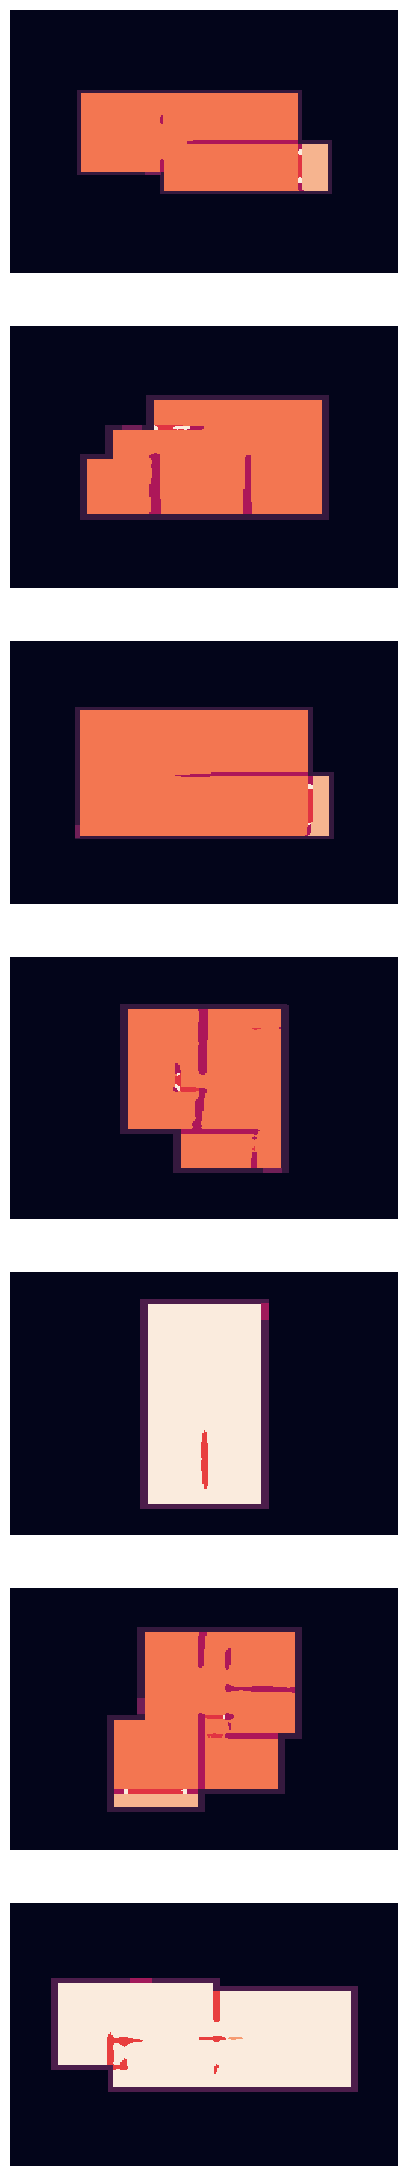

In [ ]:
fig, ax = plt.subplots(len(bad_plans), 1, figsize=(5, len(bad_plans) * 4))

for i, plan in enumerate(bad_plans):
    sns.heatmap(plan, ax=ax[i], yticklabels=False, xticklabels=False, cbar=False)

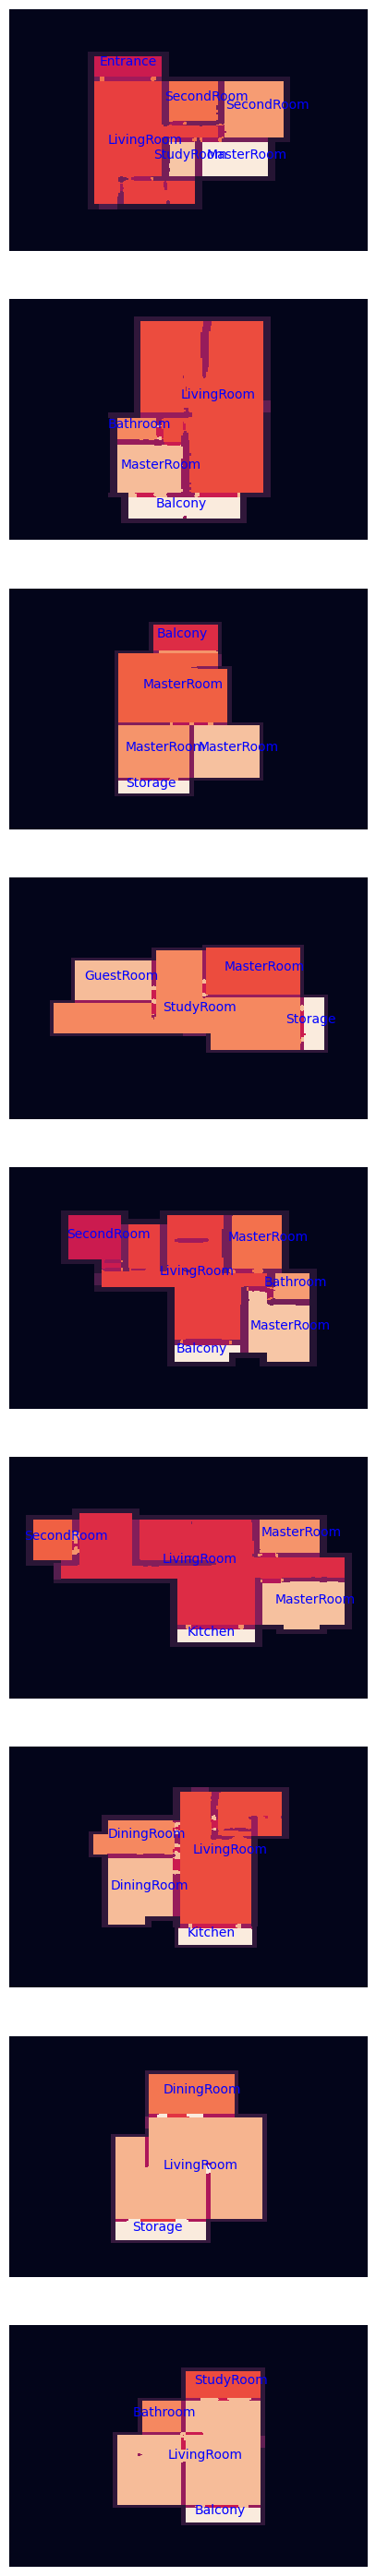

In [ ]:
vocab = get_vocab()
room_index = vocab["object_idx_to_name"]

fig, ax = plt.subplots(len(good_plans), 1, figsize=(5, len(good_plans) * 4))

for i, plan in enumerate(good_plans):
    sns.heatmap(plan, ax=ax[i], yticklabels=False, xticklabels=False, cbar=False)
    for _, node in enumerate(good_plan_nodes[i]):
        ax[i].text(
            node[0] - 20, node[1], room_index[gat_batch_pred[i][_]], color="blue"
        )

In [ ]:
torch.save(gat_batch_pred, "gat_batch_pred.pt")
np.save("batch_durations.npy", np.array(batch_durations))

In [55]:
sample_gat_batch_pred = torch.load("gat_batch_pred.pt")

In [ ]:
# Floorplan success rate
print(len(sample_gat_batch_pred))
len(sample_gat_batch_pred) / 5000

3727


0.7454

# Room Type Analysis

In [ ]:
node_pred_counts = pd.DataFrame(
    list(chain(*sample_gat_batch_pred)), columns=["node_value"]
)
node_pred_freq = (
    node_pred_counts["node_value"].apply(lambda x: int(x)).value_counts().sort_index()
)
node_pred_freq

node_value
0     2464
1     2948
2      957
3     1848
4      465
5      587
6     1848
7     1698
8      356
9     1752
10     355
11     548
12     353
Name: count, dtype: int64

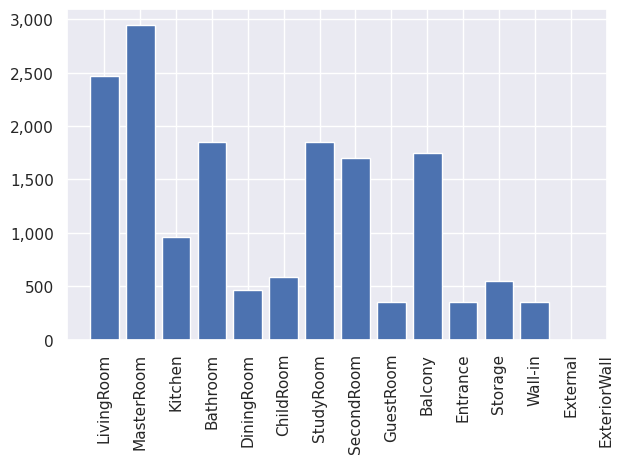

In [ ]:
fig, ax = plt.subplots()

ax.bar(node_pred_freq.index, node_pred_freq)
ax.set_xticks(range(len(room_index)))
ax.set_xticklabels(room_index, rotation=90)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

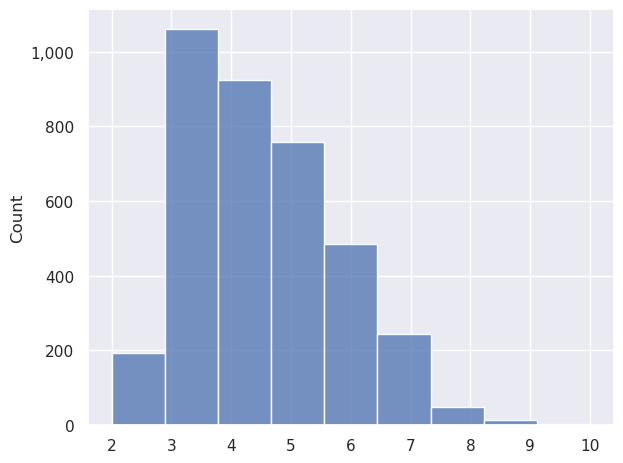

In [ ]:
fig, ax = plt.subplots()

room_counts = [len(x) for x in sample_gat_batch_pred]
sns.histplot(room_counts, ax=ax, bins=9)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

In [ ]:
node_pred_freq / len(sample_gat_batch_pred)

type_per_plan = pd.DataFrame(
    {
        "room_type": room_index[:-2],
        "avg_per_plan": node_pred_freq / len(sample_gat_batch_pred),
    }
)

type_per_plan["avg_per_plan"] = type_per_plan["avg_per_plan"].apply(
    lambda x: f"{x:.2f}"
)
type_per_plan

,room_type,avg_per_plan
node_value,,
0,LivingRoom,0.66
1,MasterRoom,0.79
2,Kitchen,0.26
3,Bathroom,0.50
4,DiningRoom,0.12
5,ChildRoom,0.16
6,StudyRoom,0.50
7,SecondRoom,0.46
8,GuestRoom,0.10
